<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/toxic_text_classification_comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [3]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [4]:

import pickle


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [6]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [8]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [10]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [11]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

In [12]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [13]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [14]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [15]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [16]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [17]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [18]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [19]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [153]:
print(f'Total comments : {len(df):,}')
print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

Total comments : 2
Total toxic comments : 16,225
Total non-toxic comments : 143,346


# Exploratory Data Analysis (EDA)

In [21]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

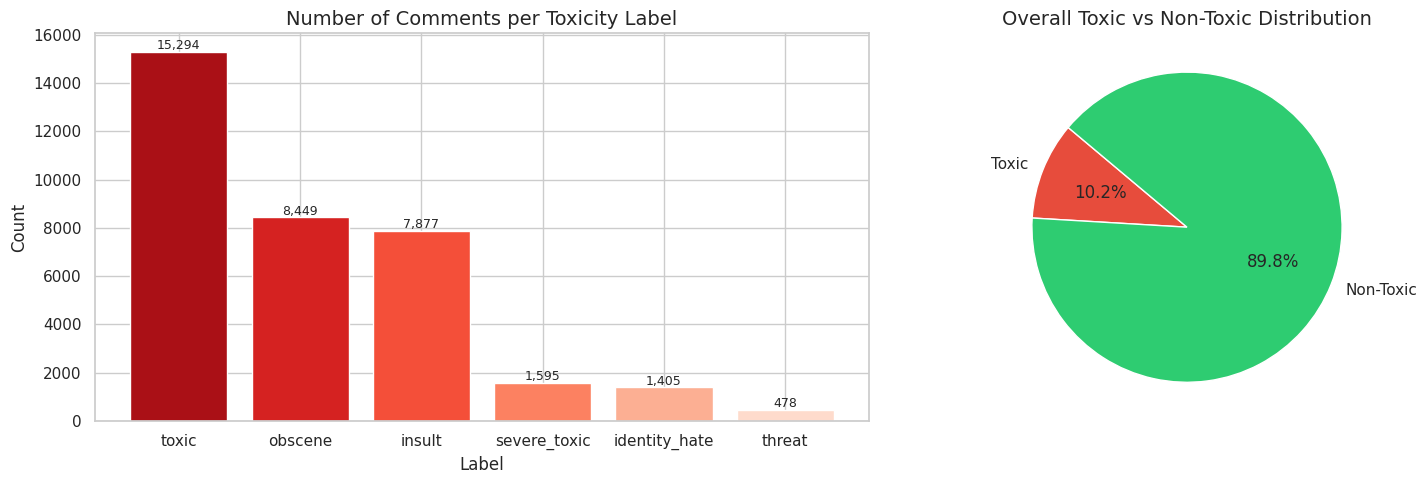

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [23]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

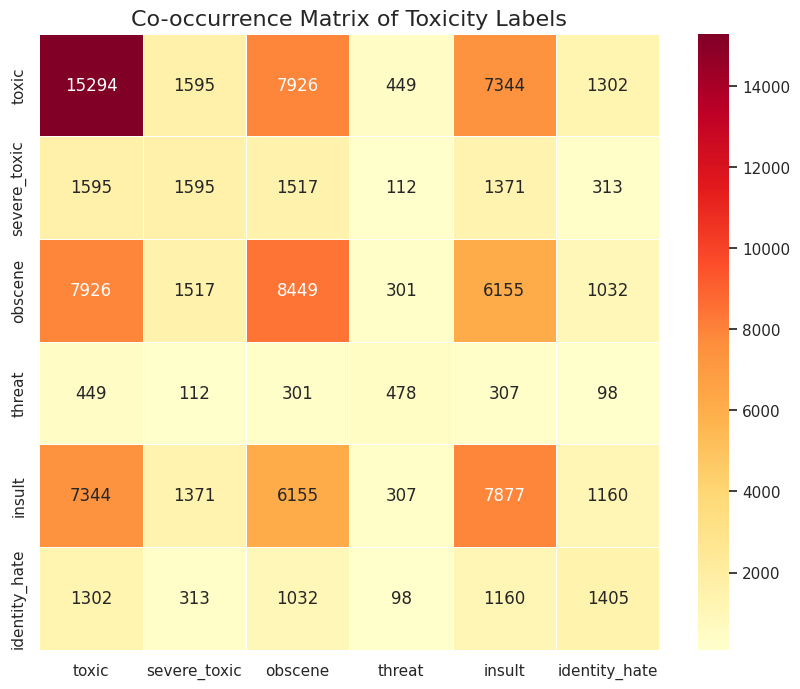

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

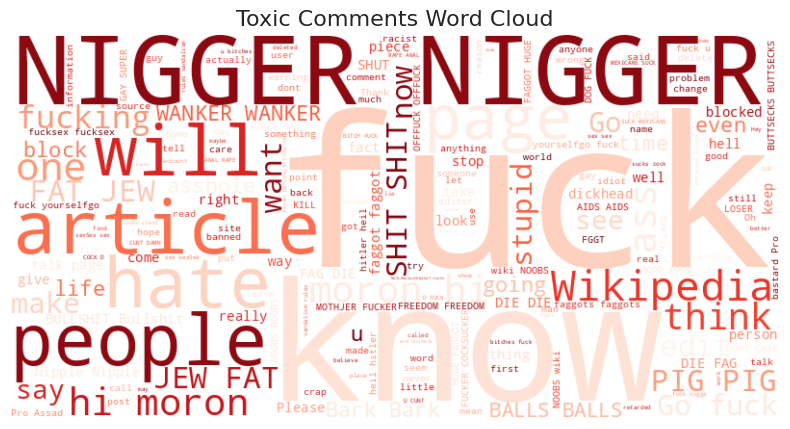

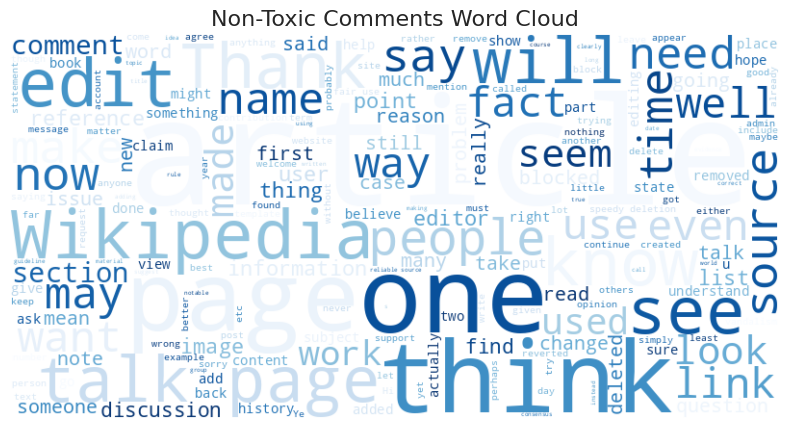

In [25]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

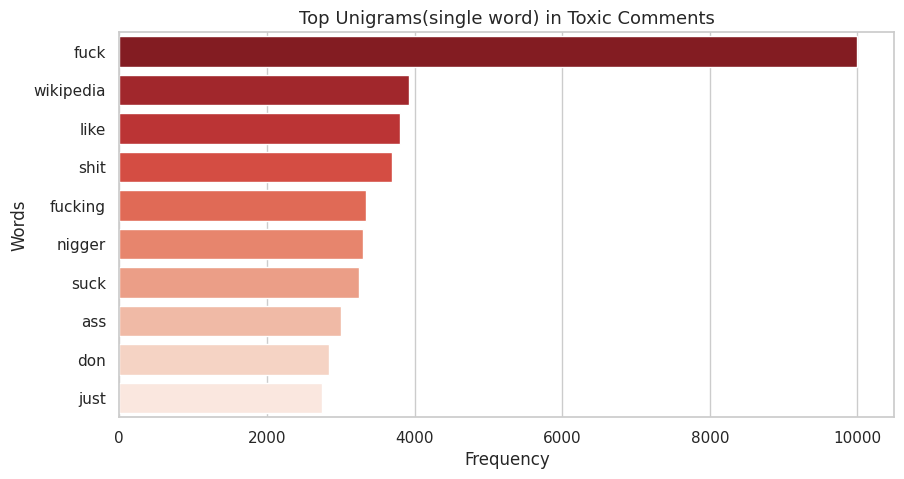

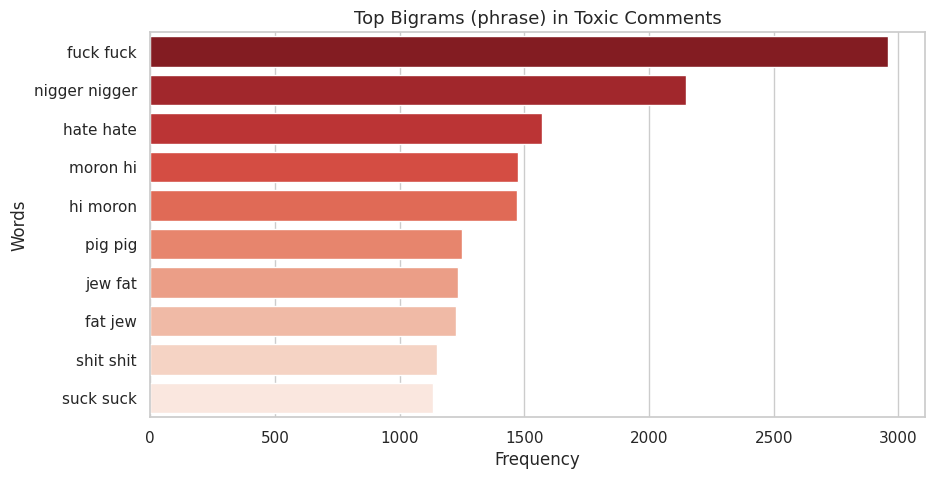

In [26]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [27]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
52068,"""\n\nAs a woman and a member of a """"Brethren""""...",0
54822,Wrestling News Love \n\nis a internet radio sh...,0
53582,Hebrew name issue re-opened,0
105062,"""\nYou know Orwell said the police messed up t...",0
123872,Hey..attention to all people out there\n\nHote...,0
146042,Misc \nSomething about his ridiculous cowboy h...,0


**Basic Preprocessing**



1.   Lower case




In [28]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [29]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [30]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [31]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [154]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [33]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [34]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 34.6 MB/s eta 0:00:00


1. Emoji to text

In [35]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [36]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [37]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [38]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [39]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [40]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [41]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [42]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [43]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [44]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [45]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [46]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [47]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [48]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
155495,"thanks, but no thanks. i don't have time like some people who spend all their free time on here. i would rather spend my free time to volunteer in real life instead of wasting it on this useless web site full of errors and communist propagandas."
99663,"I agree, but please if you really think I am a puppet file a request at WP:RFCU and clear me! I'm not a puppet, just a newbie with an unfortunate similarity in username"
22283,"Dear Lightocha, your claims of Buddhist origin of Yoga have no grounds. Read the article. Yoga has Vedic origin.\n\nThe yoga article used to have much more Buddhist information about 15 months ago, but the information was selectively deleted. \n\nCan you please show me which which 15 month version had more Buddhist information. As far as my knowledge goes, this article has always been Hindu centred which is right as well. -"
39398,. An example of one not having on would be Switzerland but I have no online citation other than I can look at all the pages and there wont be one.
158449,"Interesting, isn't it. This is the third person I've found who is blocked for merely citing UK law. Maybe these people think they are above reproach?"


Applying Basic Preprocessing

In [49]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
134976,you lengthned my block again to two weeks for what now for living admins protect me from agresor kafziel
36767,but i didnt disclosed personal information anyon ewho lives near you can know your name
87796,i am sorry plz dont block me
12450,your interpretation of the above words does not make it a personal attack it is what is in you that makes you interpret it in that way i am the author of it and hence i know what i meant take any action allowd to be vicious wilful murder for instance examine it in all lights and see if you can find that matter of fact or real existence which you call vice in whichever way you take it you find only certain passions motives volitions and thoughts there is no other matter of fact in the case the vice entirely escapes you as long as you consider the object you never can find it till you turn your reflexion into your own breast and find a sentiment of disapprobation which arises in you towards this action here is a matter of fact but tis the object of feeling not of reason hume
5716,if you will check the article at tours i rewrote the entire section you questioned i think accomadating your concerns and asked you on the talk page for your input so if needs further work i can do so i have a volume library here adn much of it is on the roman empire which of course includes the carolinians since the holy roman empire began with martels grandson charlamagne i am sorry and welcome your input to improve the article


[link text](https://)Comparison Of Raw and Basic Clean by Basic Preprocessing

In [50]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
88336,"Harl3quin... working on walkthru now, will post later 212.183.134.210",harlquin working on walkthru now will post later
78615,the administrator PhilKnight is dancing around the point. was it a personal attack that justifies a 48 hour block or not?,the administrator philknight is dancing around the point was it a personal attack that justifies a hour block or not
59815,"Or, they could change the school schedules to a more appropriate time without changing every clock in the country. Am I the only one who thinks daylight saving time is like trying to reduce traffic accidents by recalibrating all the speedometers to make people think they're going faster than they really are? 02:25 Sep 10, 2002 (UTC)",or they could change the school schedules to a more appropriate time without changing every clock in the country am i the only one who thinks daylight saving time is like trying to reduce traffic accidents by recalibrating all the speedometers to make people think theyre going faster than they really are sep utc
38186,Wop and alot of Soul groups used B3 Hammond,wop and alot of soul groups used b hammond
120294,"""\n Just wanted to make sure you saw my answer too, """"notori-ass!"""" HA, what a joke! Because I really DO want to annoy you, you useless little turd! And I(we) intend to do so, so much more than that. Careful what you wish for bitch... 69.50.214.99 """,just wanted to make sure you saw my answer too notoriass ha what a joke because i really do want to annoy you you useless little turd and iwe intend to do so so much more than that careful what you wish for bitch


Applying Advanced Preprocessing

In [51]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [52]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
71602,go back even year find israeli politician saying attack arab think win thats absurd know ton time palestinian leadership talked side mouth starting arafat old phased plan establish palestine state attack israel question explain occasionally ask palestinian street explode arafat prophet muhammad made khudaibiya agreement agreed remove title messenger allah agreement omar bin khatib others referred agreement inferior peace agreement course compare prophet say must learn step salah adin peace agreement signed inferior peace condition behind intifada lasted seven year q practical reason suggest maintain quiet despite everything arafat yes suggest maintain quiet respect agreement way prophet muhammad salah adin respected agreement signed orbit tv april khudaibiya peace example saladin speaks time islamic treaty cut short muslim group using build force lull enemy thinking war wasnt coming signed agreement oslo one objection one hundred objection arafat voice palestine radio right compared oslo accord khudaibiya truce serious look phased plan pnc look doublespeak especially stuff translate say one thing english complete opposite arabic tv radio
25289,im exactly sure hell phrase exactly mean simple fact matter even wikipedia period harassed jbhunley going month disgrace moderator seem condoning bullying behaviour censured even calling
130115,answer question newcastle rugby league purely local competition team compete best semiprofessional think really relevent added chance read guideline really rough stub
141357,think paraphrase complete left couple quote one goal century really much quote name goal known wonder goal quote ibrahimovics unique bicycle kick really think another way describe video goal
20876,one example qualifying citation directly stating puppet government


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [53]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
40087,"Oppose. We must wait, after the crisis ends scholars and intelectuals will come up with the apporpriate name, just like happened with 9/11. After 9/11's dust settled, people chose the name 9/11 not during it. So IMO we should wait.",oppose must wait crisis end scholar intelectuals come apporpriate name like happened dust settled people chose name imo wait
76657,"You could say that music - in particular The Beatles - is a huge part of the novel. I'll have to reread it once I've finished The Wind Up Bird Chronicle and jot down some notes on the themes, so we can make this page even better.",could say music particular beatles huge part novel ill reread ive finished wind bird chronicle jot note theme make page even better
136407,The personal attacks will cease. Please allow me to complete my article next time around.\n\nThankyou,personal attack cease please allow complete article next time around thankyou
27103,"St. Lachtain's GAA changes \n\nHello i received a notification a few minutes ago informing me of a rude remark I had apparentally left on the St. Lachtain's GAA page. This is not the first time I have received such notifications and similar incidents have occured in the past. I did not, in this incident as with the others make these alterations although I am in no doubt as to who did. My younger sibling wrote those things. I live some distance from my sibling in fact and have never made an account or an edit on wikipedia. My question is why am I receiving such messages, surely it must be obvious from the ip address? I agree the edits are unnacceptable but I am not is responsible for the child and his behaviour and would not like to be held to account as such. If you could get back to me on this I would greatly appreciate it.\n\nGavin",st lachtains gaa change hello received notification minute ago informing rude remark apparentally left st lachtains gaa page first time received notification similar incident occured past incident others make alteration although doubt younger sibling wrote thing live distance sibling fact never made account edit wikipedia question receiving message surely must obvious ip address agree edits unnacceptable responsible child behaviour would like held account could get back would greatly appreciate gavin
114974,Articles for Deletion debate\nThis article was to be merged with and redirected to 'somewhere' as a result of an Articles for Deletion debate. The discussion can be found here. Please do read that debate before proceeding. - - tk,article deletion debate article merged redirected somewhere result article deletion debate discussion found please read debate proceeding tk


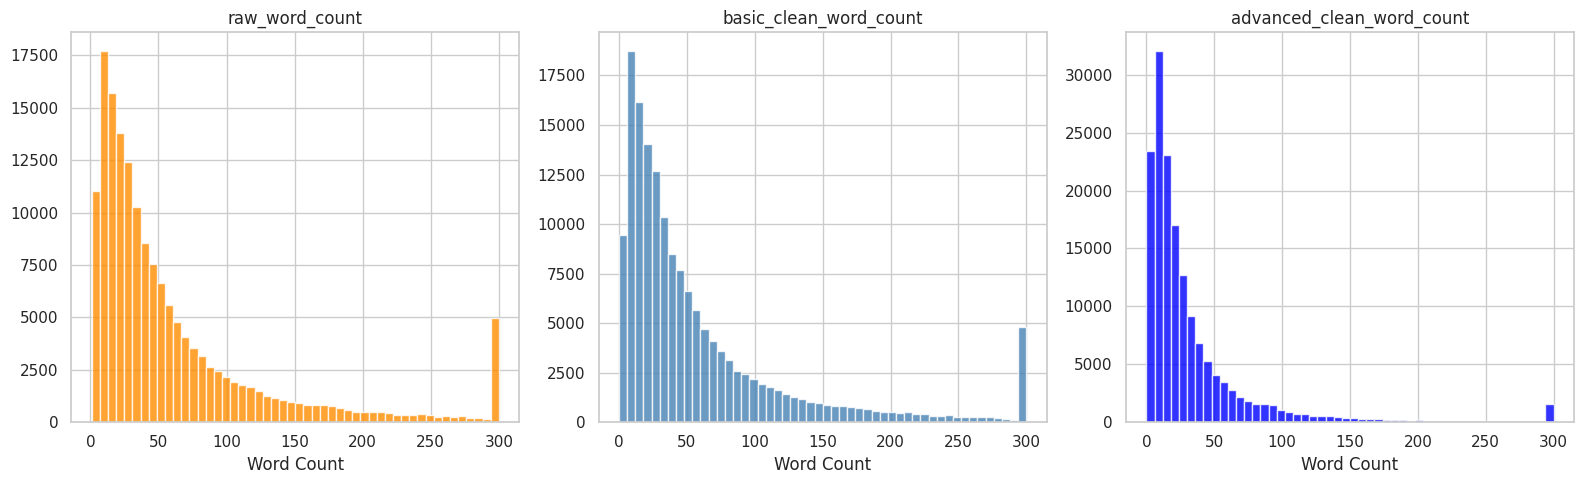

In [54]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [55]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [56]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [57]:
for i in range(2):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [59]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [61]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [62]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [63]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [64]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [65]:
train_df['comment_text'].apply(lambda x: len(str(x).split())).describe()

,comment_text
count,159571.000000
mean,67.273527
std,99.230702
min,1.000000
25%,17.000000
50%,36.000000
75%,75.000000
max,1411.000000


In [66]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 100)
LSTM shape val (15957, 100)
LSTM shape test (15958, 100)


3. BERT Tokenizer (for BERT) \
raw dataset

In [67]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [68]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [69]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [70]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [71]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score
# )

# results = {}

# def evaluate(model_name, y_true, y_pred, y_prob=None,
#              elapsed_train=None, elapsed_infer=None):

#     acc = accuracy_score(y_true, y_pred)

#     prec = precision_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     rec = recall_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     macro_f1 = f1_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     weighted_f1 = f1_score(
#         y_true, y_pred,
#         average='weighted',
#         zero_division=0
#     )

#     # ROC-AUC
#     if y_prob is not None:
#         roc_auc = roc_auc_score(
#             y_true,
#             y_prob,
#             average='macro'
#         )
#     else:
#         roc_auc = None

#     results[model_name] = {
#         'accuracy': round(acc, 4),
#         'precision': round(prec, 4),
#         'recall': round(rec, 4),
#         'macro f1': round(macro_f1, 4),
#         'weighted f1': round(weighted_f1, 4),
#         'roc-auc': round(roc_auc, 4) if roc_auc else '-',
#         'train time (s)': round(elapsed_train, 1) if elapsed_train else '-',
#         'infer time (s)': round(elapsed_infer, 1) if elapsed_infer else '-'
#     }

#     print(f'\n===== {model_name} =====')
#     print(f'Accuracy     : {acc:.4f}')
#     print(f'Precision    : {prec:.4f}')
#     print(f'Recall       : {rec:.4f}')
#     print(f'Macro F1     : {macro_f1:.4f}')
#     print(f'Weighted F1  : {weighted_f1:.4f}')

#     if roc_auc is not None:
#         print(f'ROC-AUC      : {roc_auc:.4f}')

#     if elapsed_train:
#         print(f'Train time   : {elapsed_train:.1f}s')

#     return results[model_name]

In [72]:
def plot_confusion(model_name,y_true, y_pred, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), lables):
       cm = confusion_matrix(y_true[:, lables.index(col)],
                              y_pred[:, lables.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [73]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

No need train again

In [74]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
with open('lr_raw_model.pkl', 'wb') as f:
    pickle.dump(lr_raw, f)
with open('tfidf_raw_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_raw, f)


In [75]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 17.2s


Run the training

In [76]:
with open('lr_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [77]:
with open('tfidf_raw_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

In [78]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)

probs = lr_raw.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 96.38%
obscene: 99.99%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.84%
severe_toxic: 82.45%
obscene: 96.65%

Comment: Amazing work
Prediction: Non-toxic


Evaluate the model for raw data

In [79]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 17.2s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 17.2,
 'infer time (s)': 0.0}

In [80]:
# y_prob_raw = lr_raw.predict_proba(X_test_tfidf_raw)

# evaluate(
#     'TF-IDF + LR (raw)',
#     y_test.values,
#     y_pred_raw,
#     y_prob=y_prob_raw,
#     elapsed_train=train_t,
#     elapsed_infer=infer_t
# )

Confusion plot for the model for raw data

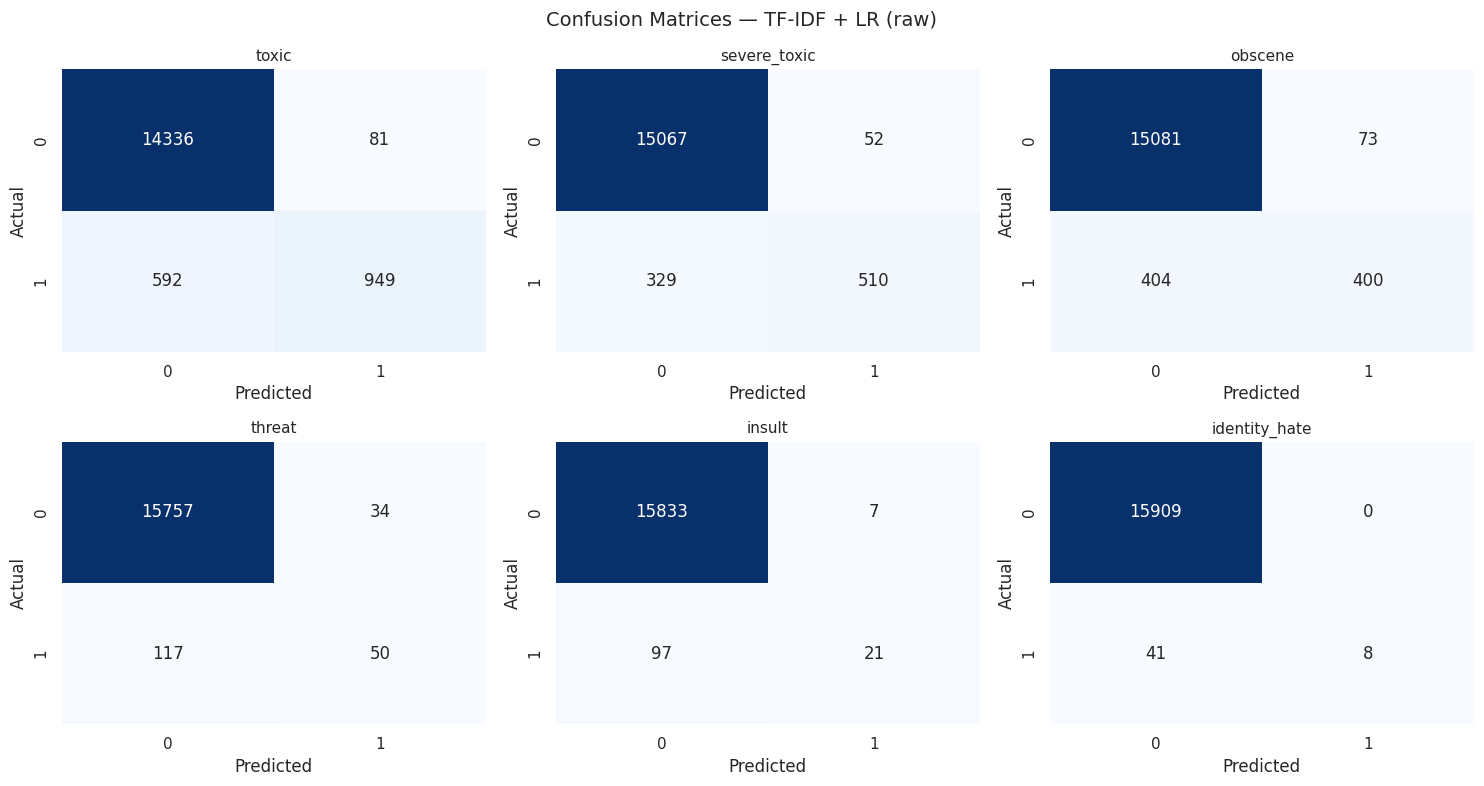

In [81]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

**Also save the training so no need to re train **

In [82]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
# lr_clean.fit(X_train_tfidf_clean, y_train)
# with open('lr_clean_model.pkl', 'wb') as f:
#     pickle.dump(lr_clean, f)
# with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
#     pickle.dump(tfidf_clean, f)

In [83]:
lr_clean.fit(X_train_tfidf_clean, y_train)
with open('lr_clean_model.pkl', 'wb') as f:
    pickle.dump(lr_clean, f)
with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)

In [84]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 11.6s


**Load the training**

In [85]:
with open('lr_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [86]:
with open('tfidf_clean_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

In [87]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 11.6s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 11.6,
 'infer time (s)': 0.0}

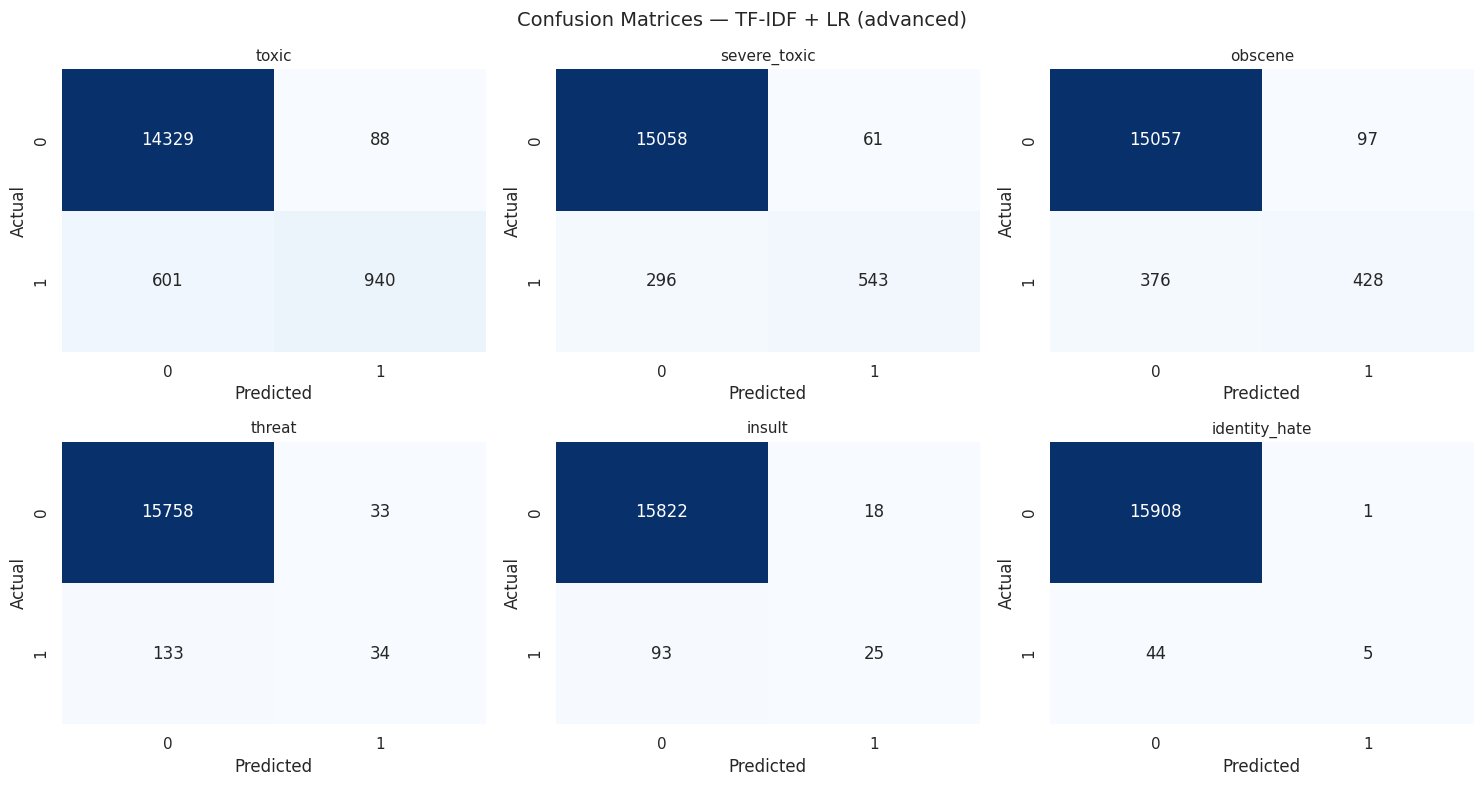

In [88]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.

In [89]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [advanced_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_clean.transform(sample_clean)

probs = lr_clean.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 98.77%
obscene: 100.00%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.96%
severe_toxic: 89.89%
obscene: 98.20%

Comment: Amazing work
Prediction: Non-toxic


# **Model 2 — TF-IDF + SVM (LinearSVC)**

**Raw version **

In [90]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

No need to re run

In [91]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
with open('svm_raw_model.pkl', 'wb') as f:
    pickle.dump(svm_raw, f)

In [92]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 12.3s


load the train

In [93]:
with open('svm_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [94]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 12.3s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 12.3,
 'infer time (s)': 0.0}

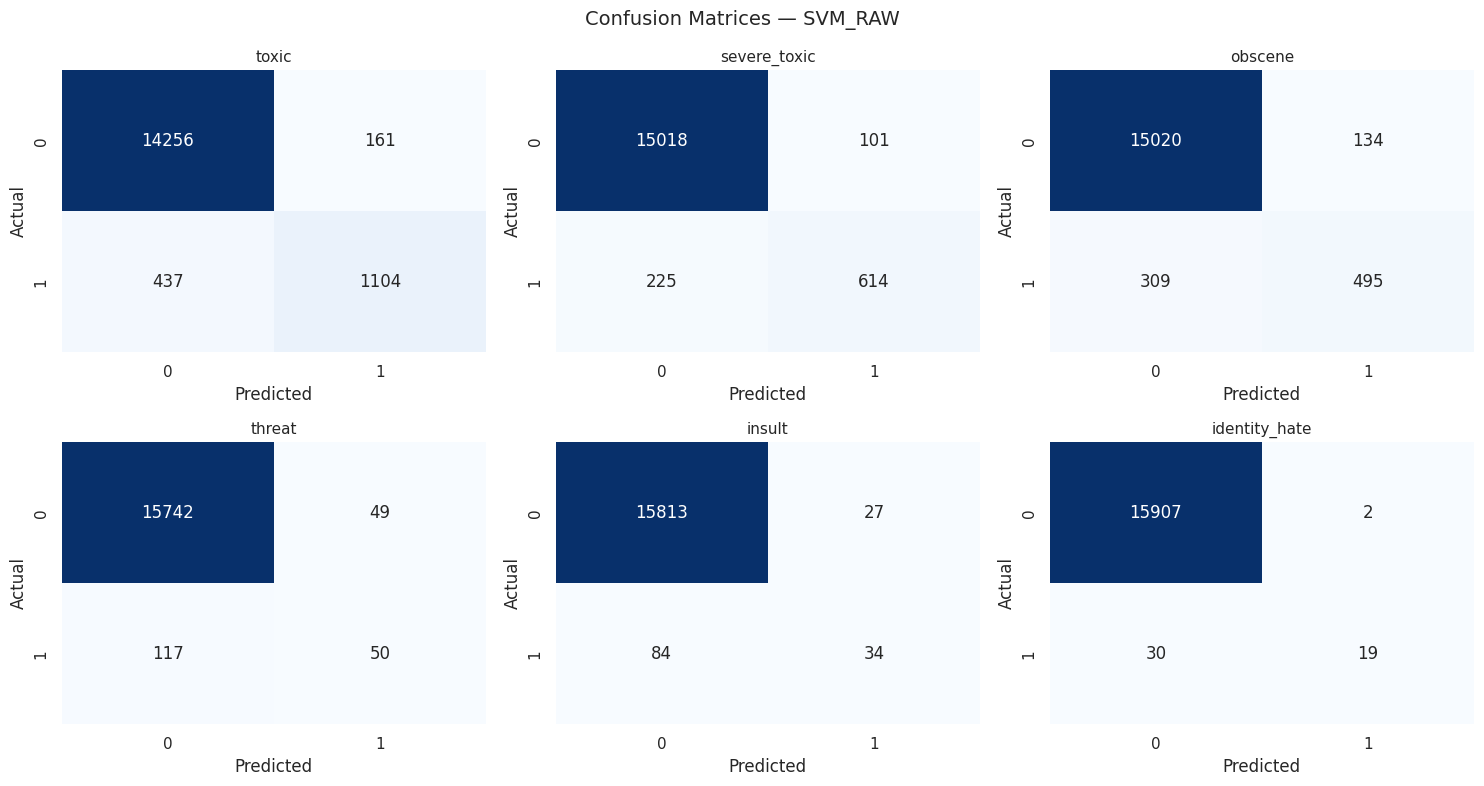

In [95]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

In [96]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


**Advanced clean version**

In [97]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
with open('svm_clean_model.pkl', 'wb') as f:
    pickle.dump(svm_clean, f)


In [98]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 7.1s


In [99]:
with open('svm_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [100]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 7.1s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 7.1,
 'infer time (s)': 0.0}

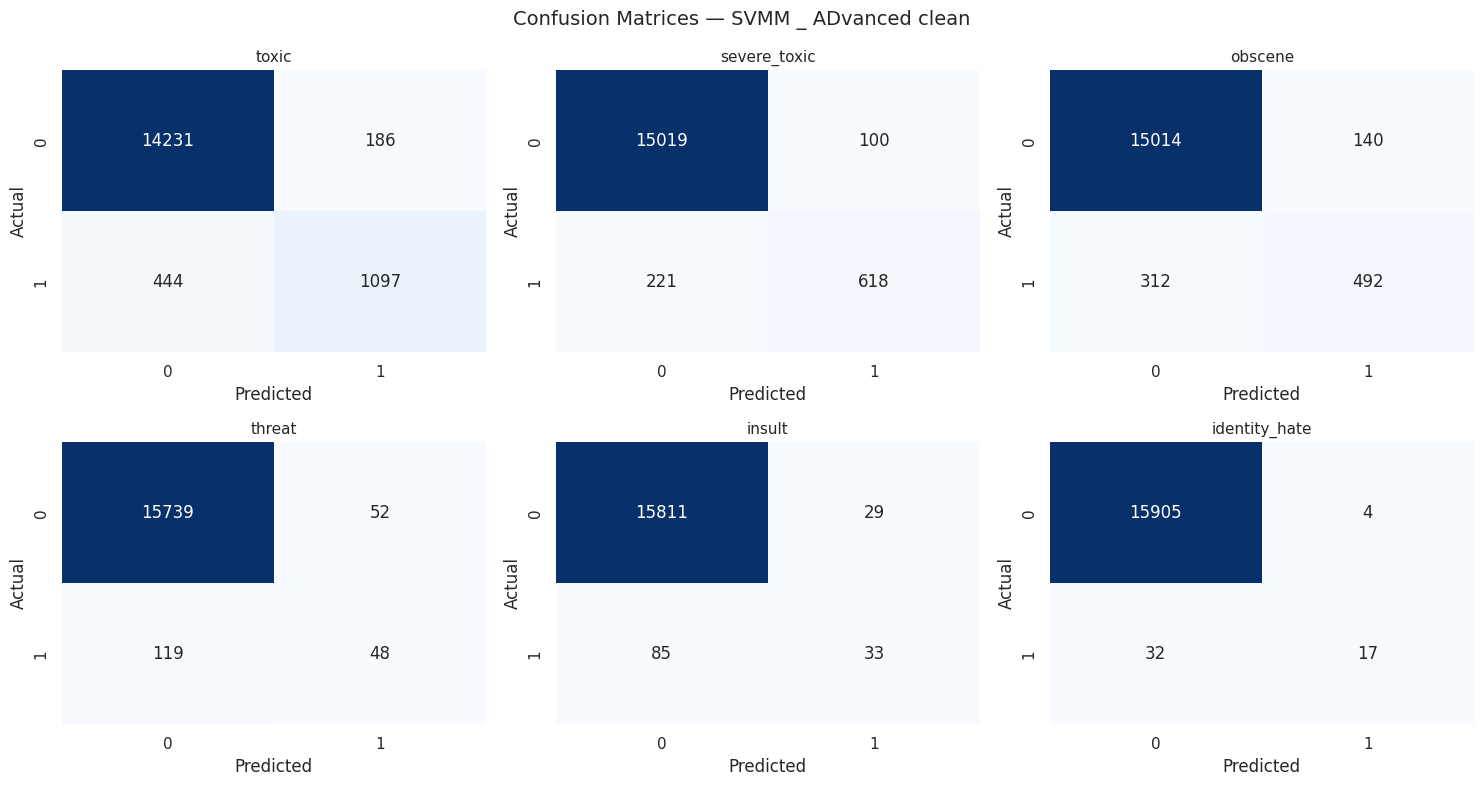

In [101]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

In [102]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

# preprocess
sample_clean = [advanced_preprocess(t) for t in sample_comments]

# tfidf transform
sample_tfidf = tfidf_raw.transform(sample_clean)

# prediction
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


# Model 3 — Bidirectional LSTM

In [103]:
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      Dropout, Bidirectional, GlobalMaxPooling1D)


Building the model



In [104]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [105]:
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Training the modle

In [106]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model




saved the train

In [107]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
lstm_model.save("bilstm_model.h5")

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8752 - loss: 0.0795 - val_accuracy: 0.9927 - val_loss: 0.0504 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9695 - loss: 0.0489 - val_accuracy: 0.9927 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9466 - loss: 0.0447 - val_accuracy: 0.9927 - val_loss: 0.0501 - learning_rate: 0.0010
Epoch 4/10
995/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9348 - loss: 0.0417
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9230 - loss: 0.0406 - val_accuracy: 0.9914 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8937 - loss: 0.0354 - val_accuracy: 0.9909 - val_loss: 0.0562 - learning_rate: 5.0000e-04


In [108]:
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')

Train time: 93.0s


In [109]:
from tensorflow.keras.models import load_model

loaded_lstm = load_model("bilstm_model.h5")

Plot training curves

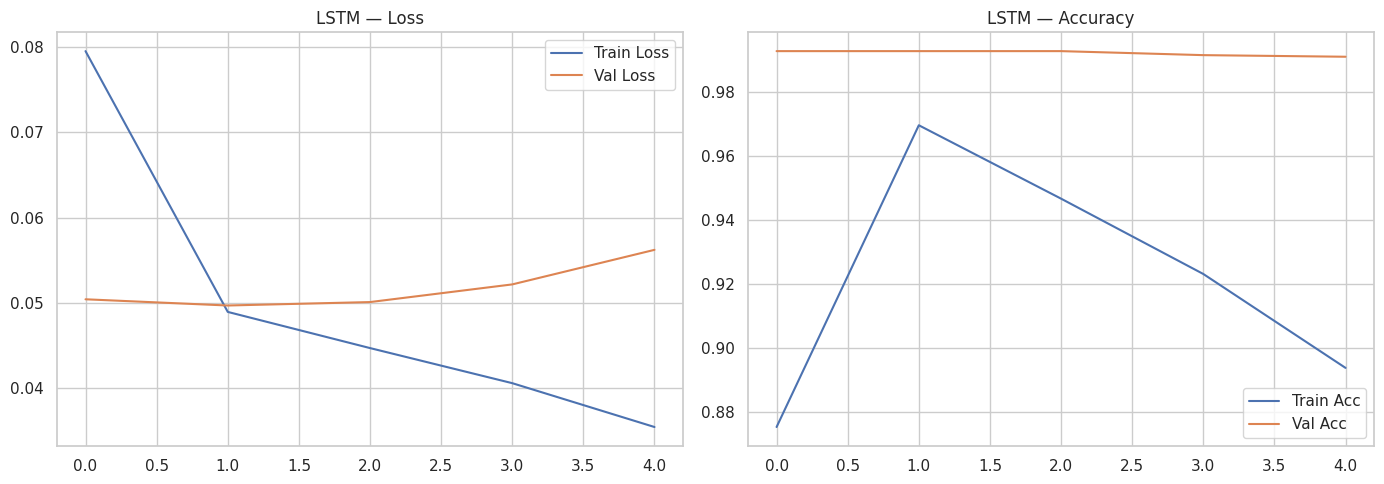

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [111]:
# Evaluate LSTM — Basic Clean (primary)
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

evaluate('LSTM — Basic Clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)

499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

===== LSTM — Basic Clean =====
  accuracy : 0.9190
  precision: 0.4847
  recall   : 0.4334
  f1 Macro : 0.4512
  train time: 93.0s


{'accuracy': 0.919,
 'precision': 0.4847,
 'recall': 0.4334,
 'f1 (macro)': 0.4512,
 'train time (s)': 93.0,
 'infer time (s)': 3.9}

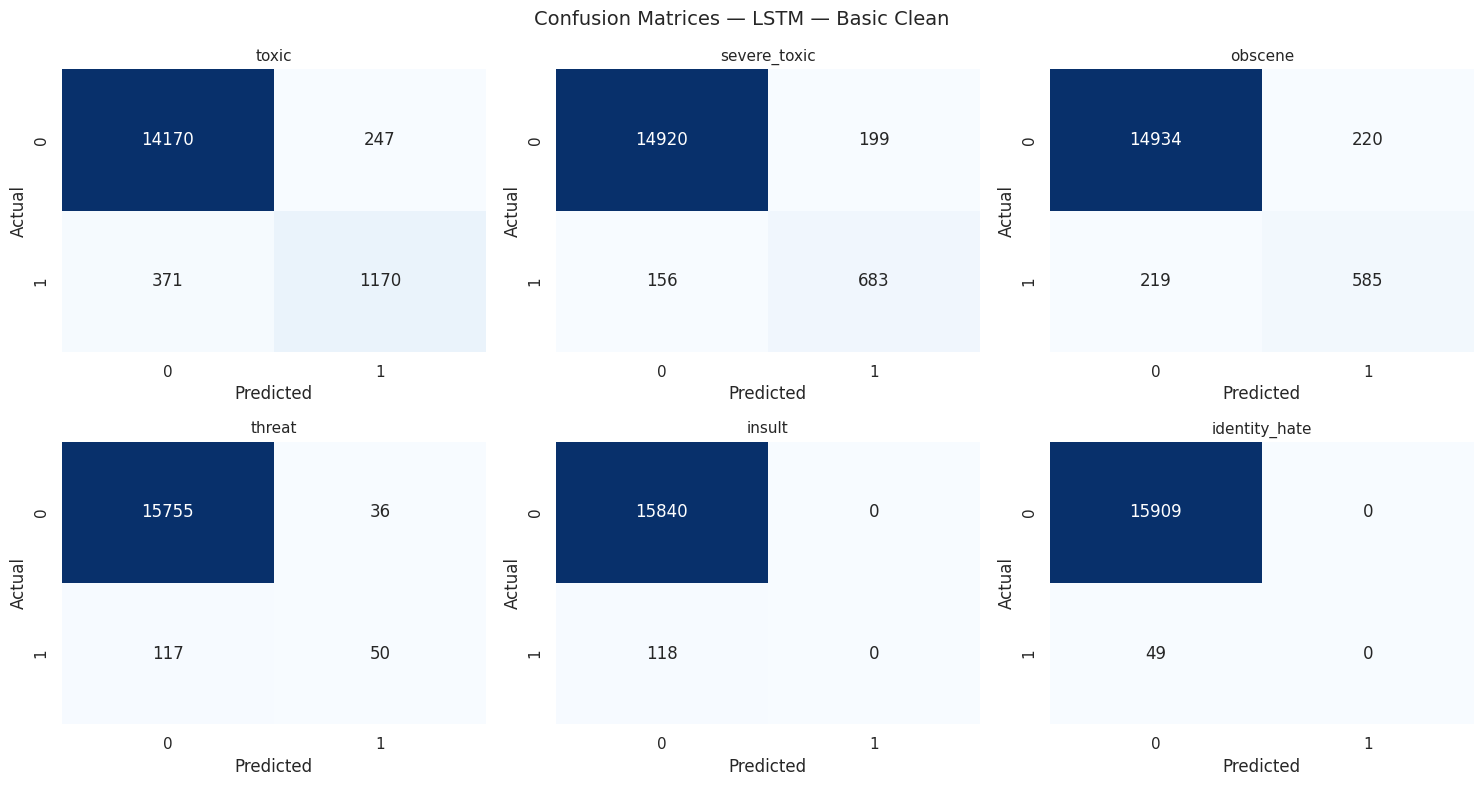

In [112]:
plot_confusion('LSTM — Basic Clean', y_test.values, y_pred_lstm,label_cols)

BiLSTM with raw data


In [113]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_model.save("lstm_raw_model.h5")


Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7849 - loss: 0.0979 - val_accuracy: 0.9927 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 2/10
497/499 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9478 - loss: 0.0513
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9486 - loss: 0.0498 - val_accuracy: 0.9927 - val_loss: 0.0501 - learning_rate: 0.0010
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9608 - loss: 0.0450 - val_accuracy: 0.9927 - val_loss: 0.0504 - learning_rate: 5.0000e-04


In [114]:
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [115]:
loaded_lstm = load_model("lstm_raw_model.h5")

In [116]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)


===== LSTM — Raw =====
  accuracy : 0.9159
  precision: 0.4654
  recall   : 0.3938
  f1 Macro : 0.3942
  train time: 36.9s


{'accuracy': 0.9159,
 'precision': 0.4654,
 'recall': 0.3938,
 'f1 (macro)': 0.3942,
 'train time (s)': 36.9,
 'infer time (s)': 5.2}

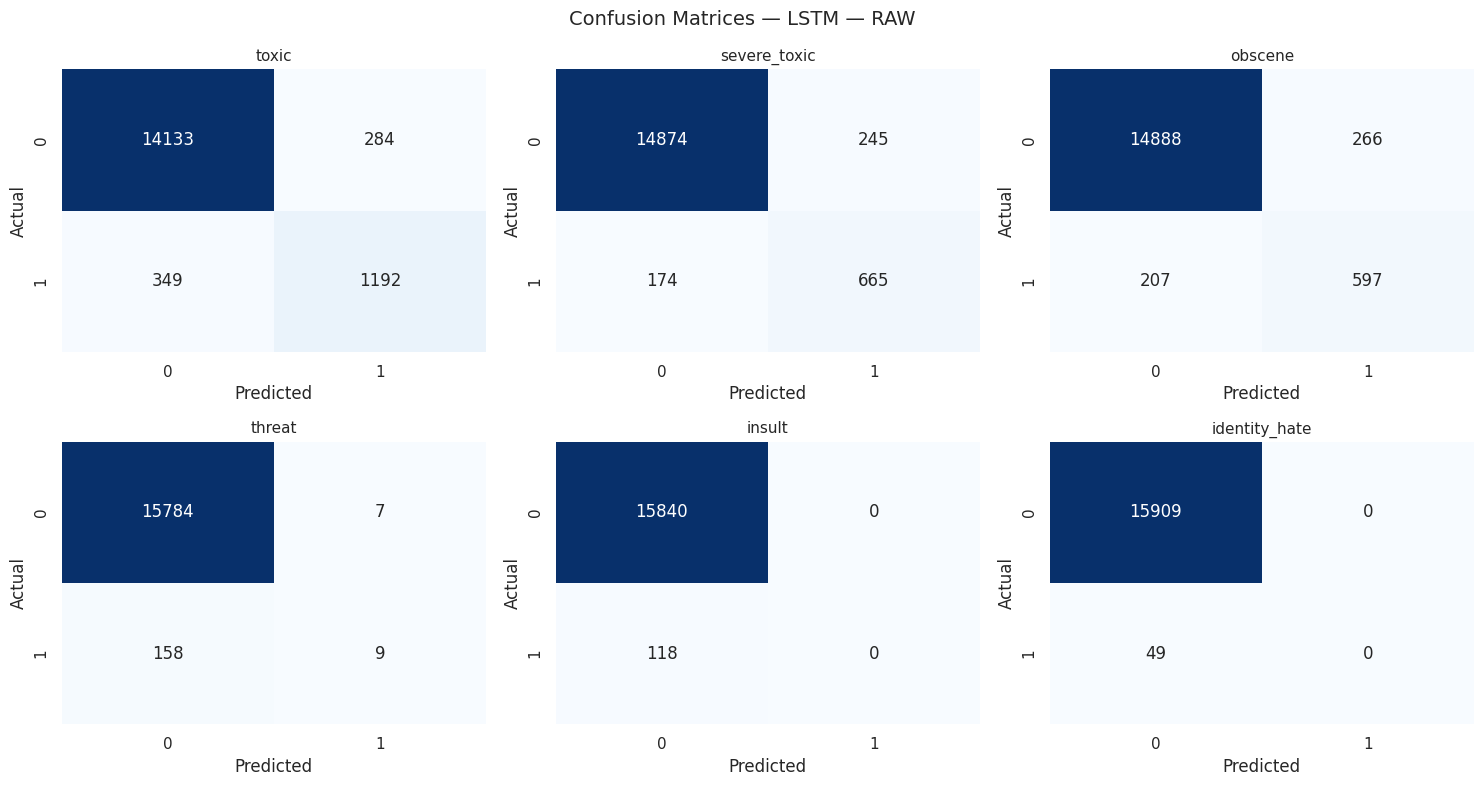

In [117]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

# Model 4 — BERT (Fine-tuned)

In [118]:
import torch
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.utils.data import Dataset, DataLoader

In [119]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.float)
        }

Device: cuda


if want to faster then bert_bath increase

or bert epochs 1

In [120]:
# Hyperparameters
BERT_BATCH = 32
BERT_EPOCHS = 1
BERT_MAX_LEN = 48

# Create datasets
train_ds = ToxicDataset(X_train['raw'].tolist(), y_train.values, Bert_tokenizer, BERT_MAX_LEN)
val_ds   = ToxicDataset(X_val['raw'].tolist(), y_val.values, Bert_tokenizer, BERT_MAX_LEN)
test_ds  = ToxicDataset(X_test['raw'].tolist(), y_test.values, Bert_tokenizer, BERT_MAX_LEN)


In [121]:
# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BERT_BATCH)
test_loader  = DataLoader(test_ds, batch_size=BERT_BATCH)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 3990
Val batches: 499


load model

In [122]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [123]:
bert_model = BertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
).to(DEVICE)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.embeddings.position_embeddi

Optimizer & scheduler

In [124]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

BERT model ready.


Training function

In [125]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):

        for batch in loader:

            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            preds = (
                torch.sigmoid(outputs.logits) > 0.5
            ).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.vstack(all_preds),
        np.vstack(all_labels)
    )

Training Loop

Expected 20 min

In [126]:
# best_val_loss = float('inf')
# bert_train_losses = []
# bert_val_losses = []

# for epoch in range(BERT_EPOCHS):

#     start = time.time()

#     train_loss, _, _ = run_epoch(
#         bert_model,
#         train_loader,
#         train=True
#     )

#     val_loss, val_preds, val_labels = run_epoch(
#         bert_model,
#         val_loader,
#         train=False
#     )

#     bert_train_losses.append(train_loss)
#     bert_val_losses.append(val_loss)

#     val_f1 = f1_score(
#         val_labels,
#         val_preds,
#         average='macro',
#         zero_division=0
#     )

#     elapsed = time.time() - start

#     print(
#         f'Epoch {epoch+1}/{BERT_EPOCHS} | '
#         f'Train Loss: {train_loss:.4f} | '
#         f'Val Loss: {val_loss:.4f} | '
#         f'Val F1: {val_f1:.4f} | '
#         f'Time: {elapsed:.0f}s'
#     )

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(
#             bert_model.state_dict(),
#             'best_bert.pt'
#         )
#     bert_train_losses.append(train_loss)
#     bert_val_losses.append(val_loss)

# print("Training complete.")

In [127]:
best_val_loss = float('inf')

bert_train_losses = []
bert_val_losses = []

for epoch in range(BERT_EPOCHS):

    start = time.time()

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_preds, val_labels = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average='macro',
        zero_division=0
    )

    elapsed = time.time() - start

    print(
        f'Epoch {epoch+1}/{BERT_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val F1: {val_f1:.4f} | '
        f'Time: {elapsed:.0f}s'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            bert_model.state_dict(),
            'best_bert.pt'
        )

Epoch 1/1 | Train Loss: 0.0777 | Val Loss: 0.0556 | Val F1: 0.3937 | Time: 1277s


In [128]:
import os
print(os.listdir())

['.config', 'word_count_distribution.png', 'svm_raw_model.pkl', 'cm_LSTM_—_Basic_Clean.png', 'lr_clean_model.pkl', 'lstm_training_curves.png', 'cm_LSTM_—_RAW.png', 'cm_TF-IDF_+_LR_(advanced).png', 'tfidf_raw_vectorizer.pkl', 'lstm_raw_model.h5', 'co_occurrence_matrix.png', 'bilstm_model.h5', 'tfidf_clean_vectorizer.pkl', 'svm_clean_model.pkl', 'cm_TF-IDF_+_LR_(raw).png', 'cm_SVMM___ADvanced_clean.png', 'best_bert.pt', 'cm_SVM_RAW.png', 'lr_raw_model.pkl', 'label_distribution.png', 'sample_data']


loss curve

In [129]:
# plt.plot(bert_train_losses, label='Train Loss')
# plt.plot(bert_val_losses, label='Val Loss')
# plt.title('Bert training and Validation loss')
# plt.xlabel('Epoch'); plt.ylabel('loss'); plt.legend()
# plt.tight_layout()
# plt.savefig('bert_loss_curve.png', dpi=150, bbox_inches='tight')
# plt.show()

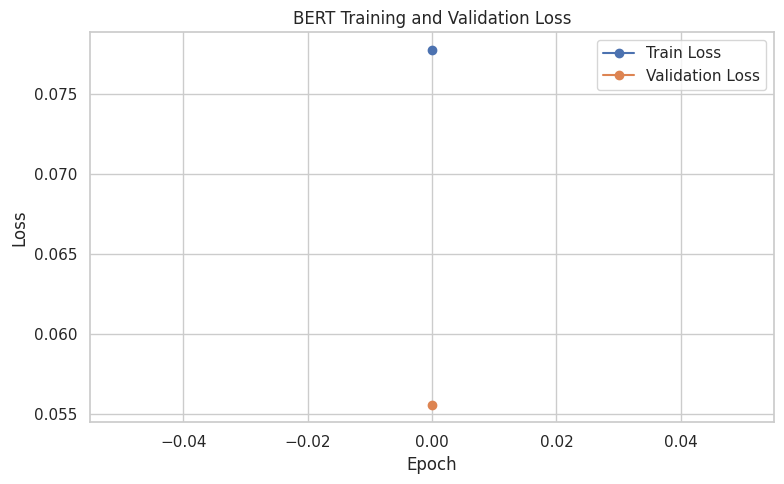

In [130]:
plt.figure(figsize=(8,5))

plt.plot(bert_train_losses, marker='o', label='Train Loss')
plt.plot(bert_val_losses, marker='o', label='Validation Loss')

plt.title('BERT Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [136]:
bert_model.load_state_dict(torch.load('best_bert.pt', map_location=DEVICE))

t0 = time.time()
_, y_pred_bert, y_true_bert = run_epoch(bert_model, test_loader, train=False)
bert_infer_t = time.time() - t0


In [137]:
evaluate('BERT — Raw', y_true_bert, y_pred_bert, elapsed, bert_infer_t)


===== BERT — Raw =====
  accuracy : 0.9162
  precision: 0.4949
  recall   : 0.3722
  f1 Macro : 0.4061
  train time: 1277.1s


{'accuracy': 0.9162,
 'precision': 0.4949,
 'recall': 0.3722,
 'f1 (macro)': 0.4061,
 'train time (s)': 1277.1,
 'infer time (s)': 51.7}

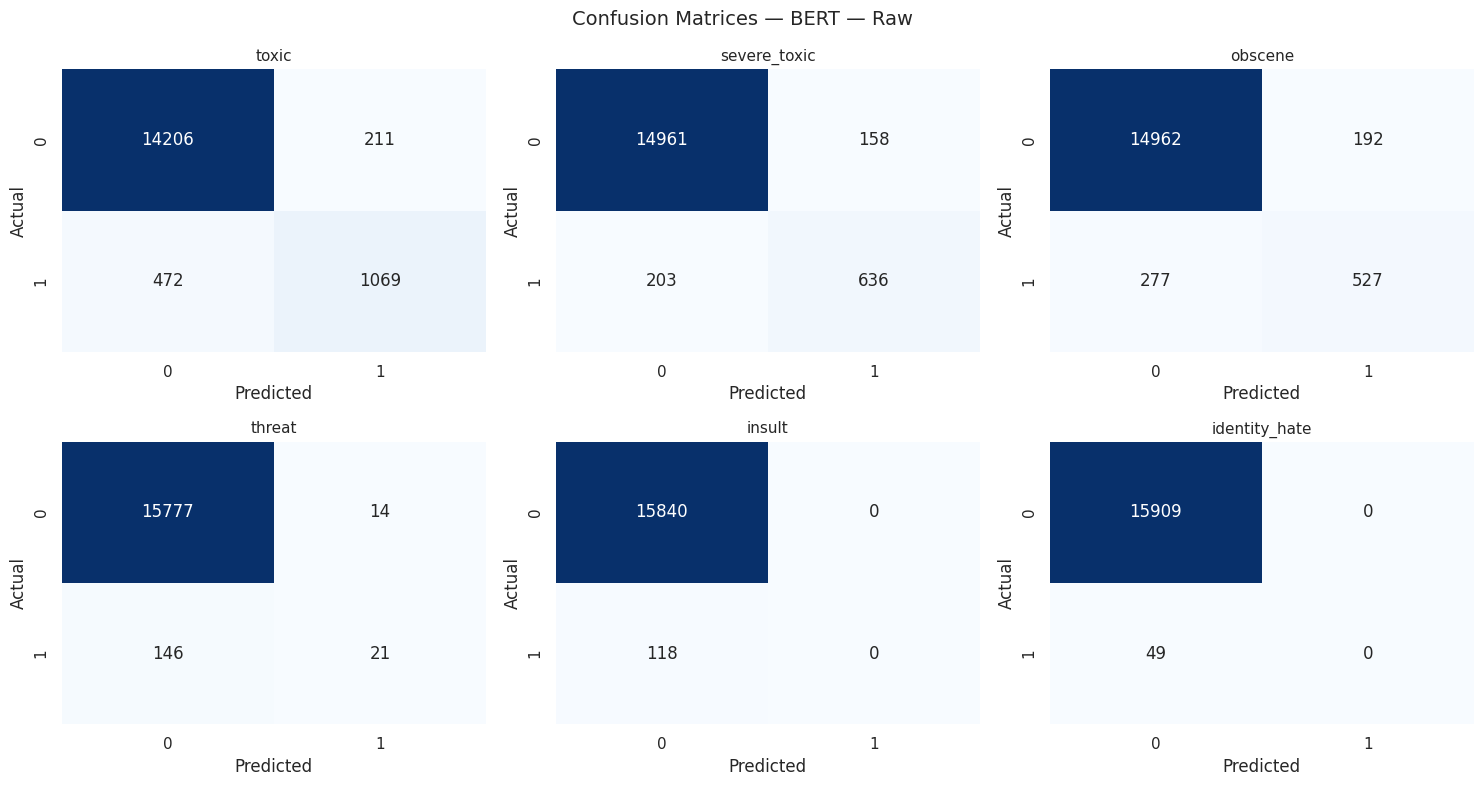

In [138]:

plot_confusion('BERT — Raw', y_true_bert, y_pred_bert)

# Comparative Analysis

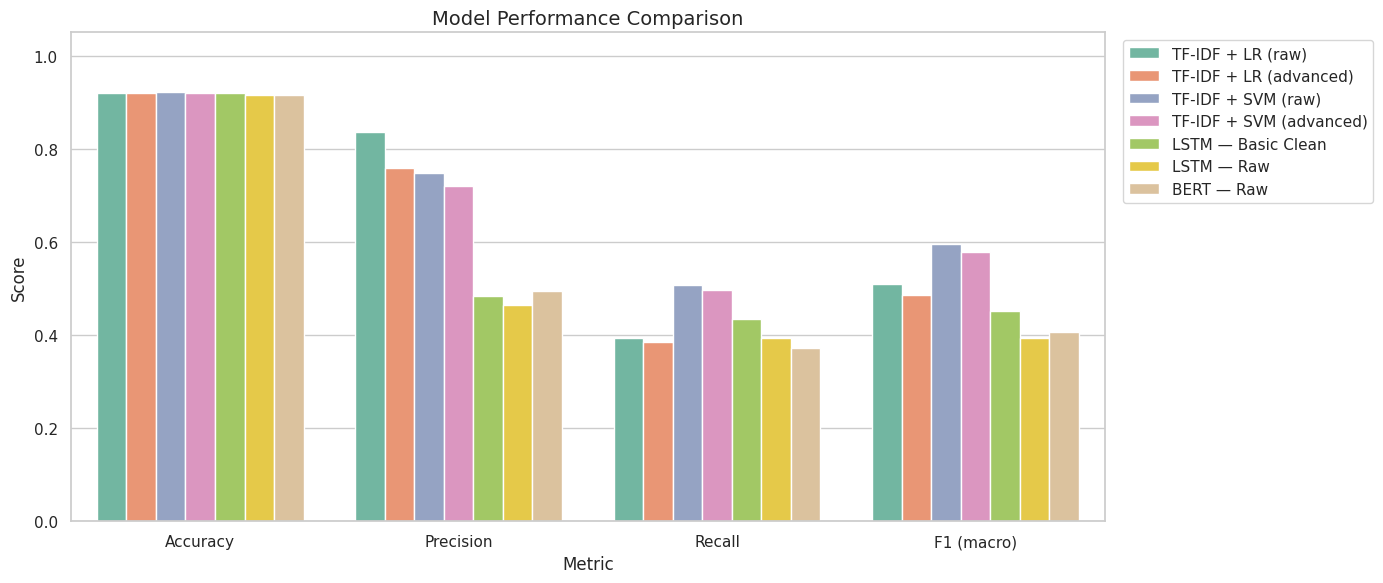

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define metric columns (changed to lowercase to match keys in the 'results' dictionary)
metric_cols = ['accuracy', 'precision', 'recall', 'f1 (macro)']

# Convert the results dictionary to a DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index': 'Model'})

# Create plot_df by selecting 'Model' and the (now correctly cased) metric columns
plot_df = results_df[['Model'] + metric_cols].copy()

# Ensure metric columns are float type
plot_df[metric_cols] = plot_df[metric_cols].astype(float)

# Melt the DataFrame for bar plotting
plot_melted = plot_df.melt(id_vars='Model', value_vars=metric_cols,
                           var_name='Metric', value_name='Score')

# Map metric names for better display on the plot
display_name_map = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1 (macro)': 'F1 (macro)'
}
plot_melted['Metric'] = plot_melted['Metric'].map(display_name_map)


plt.figure(figsize=(14, 6))
sns.barplot(data=plot_melted, x='Metric', y='Score', hue='Model',
            palette='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Preprocessing impact (raw vs clean, same architecture)

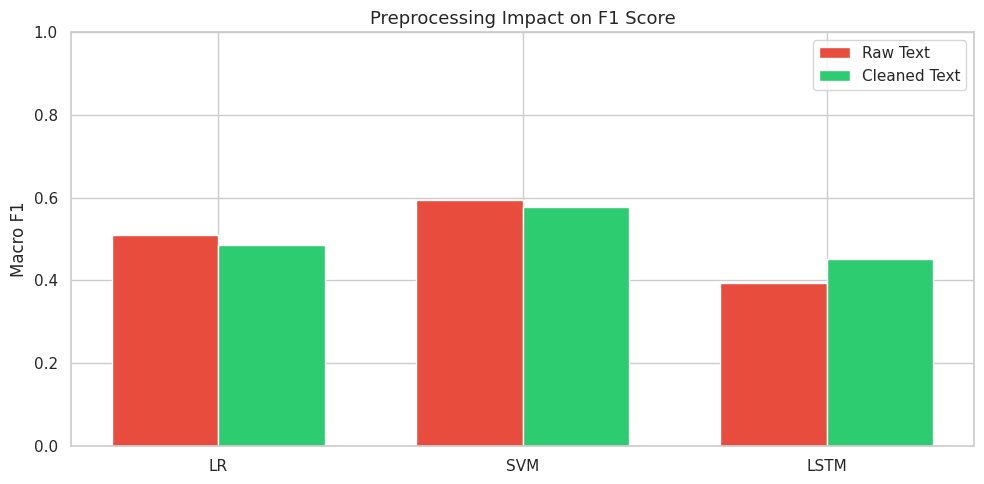

  Architecture  F1 Raw  F1 Cleaned
0           LR  0.5099      0.4852
1          SVM  0.5944      0.5780
2         LSTM  0.3942      0.4512


In [151]:
raw_models = [m for m in results if 'raw' in m.lower()]

clean_models = [
    m for m in results
    if 'clean' in m.lower() or 'advanced' in m.lower()
]

preprocess_rows = []
for arch in ['LR','SVM','LSTM']:
    raw_key   = next((m for m in raw_models   if arch.lower() in m.lower()), None)
    clean_key = next((m for m in clean_models if arch.lower() in m.lower()), None)
    if raw_key and clean_key:
        preprocess_rows.append({
            'Architecture': arch,
            'F1 Raw'      : results[raw_key]['f1 (macro)'],
            'F1 Cleaned'  : results[clean_key]['f1 (macro)']
        })

preproc_df = pd.DataFrame(preprocess_rows)

x = np.arange(len(preproc_df))
w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, preproc_df['F1 Raw'],     w, label='Raw Text',     color='#e74c3c')
ax.bar(x + w/2, preproc_df['F1 Cleaned'], w, label='Cleaned Text', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(preproc_df['Architecture'])
ax.set_title('Preprocessing Impact on F1 Score', fontsize=13)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(preproc_df)

# Training time comparison

/tmp/ipykernel_5514/3521546180.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')


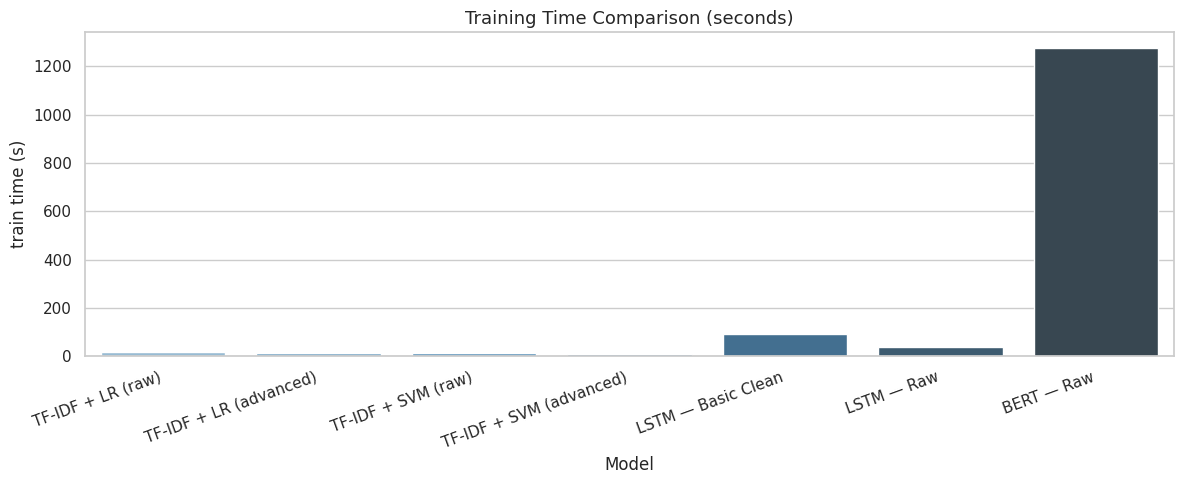

In [146]:
time_df = results_df[['Model', 'train time (s)']].copy()
time_df = time_df[time_df['train time (s)'] != '-']
time_df['train time (s)'] = time_df['train time (s)'].astype(float)

plt.figure(figsize=(12, 5))
sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')
plt.title('Training Time Comparison (seconds)', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Error Analysis — Misclassified Samples

In [148]:
# Analyse BERT misclassifications (best model)
test_texts = X_test['raw'].values

# Find samples where BERT was wrong on any label
wrong_mask = (y_true_bert != y_pred_bert).any(axis=1)
wrong_idx  = np.where(wrong_mask)[0]

print(f'Misclassified samples (BERT): {wrong_mask.sum()} / {len(y_true_bert)}')

error_df = pd.DataFrame({
    'text'       : [test_texts[i][:200] for i in wrong_idx[:20]],
    'true_labels': [dict(zip(label_cols, y_true_bert[i])) for i in wrong_idx[:20]],
    'pred_labels': [dict(zip(label_cols, y_pred_bert[i])) for i in wrong_idx[:20]]
})

pd.set_option('display.max_colwidth', 120)
error_df.head(10)

Misclassified samples (BERT): 1337 / 15958


,text,true_labels,pred_labels
0,"""I think all of you americans you have a real attitude and mental problem !\nFirst you live in a World full of consp...","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
1,"""\n\n Swedish joke #1 \n\nSince self-righteous Mr.choppers knows nothing about the USDM D15B8 which he relentlessly ...","{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
2,And this meat puppet would be whom? Tim Foxworth,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
3,Holy Jesus crap \n\nYou just commited the worst sin possible & theres no redemtion so once you die you be going to h...,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': True, 'obscene': True, 'threat': False, 'insult': False, 'identity_hate': False}"
4,"It presumes that the dumbfucks who troll about the ending have any good reason to do so, so it is biased.","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
5,2011 French Open \n\nDon't leave silly little messages on my talk page saying I haven't explained myself and revert ...,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
6,"""\n\n Oh and as far as """"not in line at all with how things are done"""", that's pure horse shit and you know it. Disa...","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
7,dude wtf \n\nI was cleaning off some junk that slipped in when I copypasted my stuff so I could add a comment when s...,"{'toxic': 0.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
8,"Lying, scheming, vindictive Weasel \n\nBurn in hell.","{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
9,Oppose Iset? Crazy.,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"


Final Summary Table

In [150]:
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

best_model = results_df.iloc[0]
print(f'\n Best model : {best_model["Model"]}')
print(f' F1 (macro) : {best_model["f1 (macro)"]}')
print(f' Accuracy   : {best_model["accuracy"]}')


FINAL RESULTS SUMMARY
                  Model  accuracy  precision  recall  f1 (macro)  train time (s)  infer time (s)
      TF-IDF + LR (raw)    0.9204     0.8366  0.3936      0.5099            17.2             0.0
 TF-IDF + LR (advanced)    0.9189     0.7585  0.3845      0.4852            11.6             0.0
     TF-IDF + SVM (raw)    0.9209     0.7476  0.5065      0.5944            12.3             0.0
TF-IDF + SVM (advanced)    0.9187     0.7193  0.4957      0.5780             7.1             0.0
     LSTM — Basic Clean    0.9190     0.4847  0.4334      0.4512            93.0             3.9
             LSTM — Raw    0.9159     0.4654  0.3938      0.3942            36.9             5.2
             BERT — Raw    0.9162     0.4949  0.3722      0.4061          1277.1            51.7

 Best model : TF-IDF + LR (raw)
 F1 (macro) : 0.5099
 Accuracy   : 0.9204
